### Duel output UNet on pennate diatoms - separating overlapping cells
### Rayna Hamilton
### May 8, 2025

We will have trained a UNet neural network to detect the locations of pennate diatom cells in strained microscopy images in train_unet.ipynb.  We noted in 2_assess_unet.ipynb that intersecting and overlapping cells are currently considered as a single object, so let's see if we can separate this.  I am going to simply leverage the long, skinny cell shape and try to find the longest lines spanning a segmentation, then separate out the pixels which are contained within each line.

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
# %matplotlib inline

from skimage.io import imread, imshow
import os
import math
from math import sqrt
import cv2

In [2]:
images=[]
image_names=[]
input_folder="../../predictions/masks/"
for file in os.listdir(input_folder):
    if file.endswith(".jpg"):
        images.append(imread(f"{input_folder}/{file}"))
        image_names.append(file)
        images[-1]=images[-1]/255


Show a sample prediction:

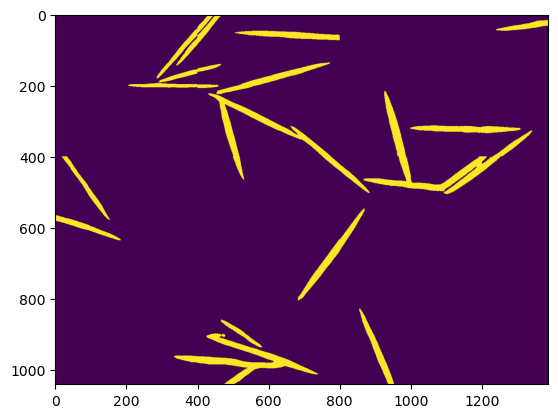

In [3]:
plt.imshow(images[0])

I actually have two functions below to separate out similar looking lines in an image - one compares the start/end points and slopes while the other compares the number of pixels shared.  This is necessary because the latter approach is more useful for our purposes, but is also very inefficient and doesn't complete in a reasonable amount of time with the number of lines generally found.  As such the slope and start/end point comparison is first used to narrow down the list.

In [4]:
def remove_overlapping_lines(lines,slope_threshold=0.2,distance_threshold=4):
    '''
    For an array of line coordinates, finds pairs of lines with start or end points within distance_threshold of each other and slopes within slope_threshold of each other, then removes the shorter line.
    Parameters:
    lines: list of coordinates of the form [x1,y1,x2,y2]
    slope_threshold: Maximum difference in slope for two nearby lines to be considered identical
    distance_threshold: Maximum distance between endpoints of a line for them to be considered identical.
    '''
    line_slopes=[]
    #first re-sort lines so that the first x-coordinate is always less than the second-this ensures consistent slope comparisons
    for i,line in enumerate(lines):
        x11,y11,x12,y12=line
        if x11>x12:
                x11,y11,x12,y12=x12,y12,x11,y11
        lines[i]=x11,y11,x12,y12
        line_slopes.append((line[3]-line[1])/(line[2]-line[0])) 
    
    indices_to_remove=[]
    overlap_found=True #whether a since pair of identical lines has been found this iteration - we can stop the loop once no more pairs have been found
    while overlap_found:
        overlap_found=False
        for i,slope1 in enumerate(line_slopes):
            for j,slope2 in enumerate(line_slopes):
                if (i not in indices_to_remove and j not in indices_to_remove) and i<j:
                    if abs(slope2-slope1)<=slope_threshold: #examine pairs of lines with slopes within slope threshold
                        line1,line2=lines[i],lines[j]
                        x11,y11,x12,y12=line1 #first x coordinate, first y coordinate, second x coordinate, second y coordinate of line 1
                        x21,y21,x22,y22=line2 #first x coordinate, first y coordinate, second x coordinate, second y coordinate of line 2
                        if (sqrt((x11-x21)**2+(y11-y21)**2)<=distance_threshold) or (sqrt((x11-x22)**2+(y11-y22)**2)<=distance_threshold) or (sqrt((x12-x21)**2+(y12-y21)**2)<=distance_threshold) or (sqrt((x12-x22)**2+(y12-y22)**2)<=distance_threshold):
                            #Keep longer line:
                            overlap_found=True
                            if sqrt((x11-x12)**2 + (y11-y12)**2) > sqrt((x21-x22)**2 + (y21-y22)**2):
                                indices_to_remove.append(j) # remove smaller line j
                            else:
                                indices_to_remove.append(i) # remove smaller line i
    new_lines=[]
    for i,line in enumerate(lines):
        if i not in indices_to_remove:
            x1,y1,x2,y2=line
            new_lines.append(line)
    #print(f"Removed {len(set(indices_to_remove))} very similar lines.")
    return new_lines

In [5]:
def remove_intersecting_lines(lines,coordinates):
    '''
    For an array of line coordinates, repeatedly looks for lines with large numbers of overlapping pixels and removes the smaller line.
    Parameters:
    lines: list of coordinates of the form [x1,y1,x2,y2]
    coordinates: dictionary of cell coordinates where each key is of the form "{x},{y}"
    '''
    indices_to_remove=[]
    overlap_found=True
    while overlap_found:
        overlap_found=False
        for i,line1 in enumerate(lines):
            for j,line2 in enumerate(lines):
                if (i not in indices_to_remove and j not in indices_to_remove) and i<j:
                    # To determine how many pixels overlap in two lines, we draw each line on a blank image and use the np.nonzero() function to return all non-zero positions
                    
                    # create blank images:
                    imagei,imagej=np.zeros((1388,1388)),np.zeros((1388,1388))
                    x11,y11,x12,y12=line1 #first x coordinate, first y coordinate, second x coordinate, second y coordinate of line 1
                    x21,y21,x22,y22=line2 #first x coordinate, first y coordinate, second x coordinate, second y coordinate of line 2
                    
                    # draw and get coordinates of first line:
                    cv2.line(imagei,(x11,y11),(x12,y12),255,20)
                    i_coordinates=[]
                    for y,x in zip(*np.nonzero(imagei)):
                        if f"{x},{y}" in coordinates.keys():
                            i_coordinates.append(f"{x},{y}")
                    
                    # draw and get coordinates of second line:
                    cv2.line(imagej,(x21,y21),(x22,y22),255,20)
                    j_coordinates=[]
                    for y,x in zip(*np.nonzero(imagej)):
                        if f"{x},{y}" in coordinates.keys():
                            j_coordinates.append(f"{x},{y}")

                    # get coordinates found in both images
                    intersection=[val for val in i_coordinates if val in j_coordinates]
                    if len(i_coordinates)<200:
                        indices_to_remove.append(i)
                        #print(f"Removing {line1} due to insufficient size {len(i_coordinates)}.")
                        continue
                    if len(j_coordinates)<200:
                        indices_to_remove.append(j)
                        #print(f"Removing {line2} due to insufficient size {len(j_coordinates)}.")
                        continue

                    # if the proportion of either line that is contained within the other line exceeds the threshold 0.4, remove the shorter line
                    if len(intersection)/len(i_coordinates)>0.4 or len(intersection)/len(j_coordinates)>0.4:
                        overlap_found=True
                        if sqrt((x11-x12)**2 + (y11-y12)**2) > sqrt((x21-x22)**2 + (y21-y22)**2):
                            indices_to_remove.append(j)
                            #print(f"Removing {line2} due to {line1}")
                        else:
                            indices_to_remove.append(i)
                            #print(f"Removing {line1} due to {line2}")

    new_lines=[]
    for i,line in enumerate(lines):
        if i not in indices_to_remove:
            x1,y1,x2,y2=line
            new_lines.append(line)
    #print(f"Removed {len(set(indices_to_remove))} very similar lines.")
    return new_lines

In [6]:
def get_pixels_from_line(line):
    '''
    Returns all pixels spanned by a line with specified start and end points.
    line: coordinates of the form [x1,y1,x2,y2]
    '''
    imagei=np.zeros((1388,1388))
    x1,y1,x2,y2=line
    cv2.line(imagei,(x1,y1),(x2,y2),255,20) 
    i_coordinates=dict()
    max_x,max_y=0,0
    for y,x in zip(*np.nonzero(imagei)):
        i_coordinates[f"{x},{y}"]=""
        if x>max_x:
            max_x=x
        if y>max_y:
            max_y=y
    return i_coordinates

In [7]:
def get_overlap_proportion(line,coordinates):
    '''
    Determines the proportion of a segmentation mask that is covered by a given line.
    Parameters:
    lines: coordinates of the form [x1,y1,x2,y2]
    coordinates: dictionary of cell coordinates where each key is of the form "{x},{y}"
    '''
    imagei=np.zeros((1040,1388))
    x1,y1,x2,y2=line
    cv2.line(imagei,(x1,y1),(x2,y2),255,20)
    #if abs(slope2-slope1)<=slope_threshold: 
    i_coordinates=[]
    for y,x in zip(*np.nonzero(imagei)):
        if f"{x},{y}" in coordinates.keys():
            i_coordinates.append(f"{x},{y}")
    return len(i_coordinates)/len(coordinates)
                        

In [12]:
def get_distance(coordinates1,coordinates2):
    '''
    Returns the distance between two coordinates in 2d space.
    Parameters:
    coordinates1: first coordinate of the form "{x},{y}"
    coordinates2: second coordinate of the form "{x},{y}"
    '''
    x1,y1,x2,y2=int(coordinates1.split(",")[0]),int(coordinates1.split(",")[1]),int(coordinates2.split(",")[0]),int(coordinates2.split(",")[1])
    return math.sqrt(((y2-y1)**2)+((x2-x1)**2))

def check_line_fill(coordinates,x1,y1,x2,y2):
    '''
    Similar to get_overlap_proportion, but models lines as single pixel width and determines how many pixels along the line intersect with cell coordinates.
    '''
    if x1>x2:
        x1,y1,x2,y2=x2,y2,x1,y1
    slope=(y2-y1)/(x2-x1)
    current_x,current_y=x1,y1
    total_steps,matching_steps=0,0
    while current_x<=x2:
        if f"{int(current_x)},{int(current_y)}" in coordinates.keys():
            matching_steps+=1
        total_steps+=1
        current_x,current_y=current_x+1,current_y+slope
    return matching_steps/total_steps
    
def get_blobs(array):
    '''
    From 2_assess_unet.ipynb - Finds all non-overlapping objects (blobs) within a segmentation mask, and returns an image with each blob as a different colour.
    Parameters:
    array: 2d numpy array when non-zero values indicate that a cell is present at the specific position.
    '''
    segmented_cells=np.zeros((1040,1388,3), dtype=np.uint8)
    coordinates_to_blobs=dict()
    current_blob=-1
    clean_array=np.copy(array)
    blob_sizes=[]
    for i in range(0,len(array)):
        for j in range(0,len(array[i])):    
            if array[i,j]==1 and f"{i},{j}" not in coordinates_to_blobs.keys():
                red,green,blue=np.random.randint(50,255),np.random.randint(50,255),np.random.randint(50,255)
                #start a new blob
                current_blob+=1
                coordinates_to_check=[f"{i},{j}"]
                x,y=i,j
                while True:#expand outwards from current pixel position in all directions until no more filled coordinates are found
                    segmented_cells[x,y,0]=red
                    segmented_cells[x,y,1]=green
                    segmented_cells[x,y,2]=blue
                    coordinates_to_blobs[f"{x},{y}"]=current_blob
                    #check all four surrounding pixels
                    if x>0 and array[x-1,y]>0 and f"{x-1},{y}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x-1},{y}")
                    if x<len(array)-1 and array[x+1,y]>0 and f"{x+1},{y}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x+1},{y}")
                    if y>0 and array[x,y-1]>0 and f"{x},{y-1}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x},{y-1}")
                    if y<len(array[0])-1 and array[x,y+1]>0 and f"{x},{y+1}" not in coordinates_to_blobs.keys():
                        coordinates_to_check.append(f"{x},{y+1}")
                    x=int(coordinates_to_check[-1].split(",")[0])
                    y=int(coordinates_to_check[-1].split(",")[1])
                    coordinates_to_check=coordinates_to_check[:-1]
                    if len(coordinates_to_check)==0:
                        blob_sizes.append(sum([val==current_blob for val in list(coordinates_to_blobs.values())]))
                        break
    return coordinates_to_blobs,blob_sizes,segmented_cells
    
def separate_single_from_multi_cell(image,coordinates_to_blobs,min_line_length=150,min_overlap_proportion=0.8):
    '''
    For each distinct blob (pixels touching each other) in a segmentation, tries to find the single longest line within a blob by combining pairs of start and end coordinates from the edges of the blob.
    If the longest line has substantial pixel overlap with the blob, assume that this is a single-cell blob and return the blob unaltered.
    Otherwise, assume that the blob is multi-cell and:
        - Find all possible lines within a blob passing an overlap and line length threshold
        - Filter down this line list using remove_overlapping_lines and remove_intersecting_lines
        - Separate the blob regions based on whether they intersect with each of the final non-redundant lines, and remove all regions spanned by multiple lines
    Parameters:
    image: 2d numpy array when non-zero values indicate that a cell is present at the specific position.
    coordinates_to_blobs: dictionary of coordinates where keys are of the form "{x},{y}" and values indicate the blob that the coordinate belongs to.
    min_line_length: minimum length for a line to be considered a cell
    min_overlap_proportion: minimum proportion of a line that must overlap with segmented coordinates to be considered
    '''
    coordinates_to_keep=dict()
    annotated_image=np.copy(image)
    single_cell_image=np.zeros(image.shape)
    blobs_to_keep=list(set(coordinates_to_blobs.values()))
    
    cell_number=0
    for blob in blobs_to_keep:
        coordinates={coordinate:"" for coordinate,blob1 in coordinates_to_blobs.items() if blob1==blob}
        longest_line_coordinates=["",""]
        longest_line=-1
        coordinates_to_check=dict()

        #get just candidate coordinates on the edges of the blob to reduce redundant computations
        for coordinate in coordinates.keys():
            x,y=int(coordinate.split(",")[0]),int(coordinate.split(",")[1])
            if f"{x-1},{y}" not in coordinates.keys() or f"{x+1},{y}" not in coordinates.keys() or f"{x},{y-1}" not in coordinates.keys()  or f"{x},{y+1}" not in coordinates.keys():
                coordinates_to_check[coordinate]=""

        #get the single longest line connecting pairs of coordinates
        for coordinate1 in coordinates_to_check.keys():
            for coordinate2 in coordinates_to_check.keys():
                if coordinate1!=coordinate2:
                    line_length=get_distance(coordinate1,coordinate2)
                    if line_length>=min_line_length and line_length>longest_line:
                        longest_line=line_length
                        longest_line_coordinates=[coordinate1,coordinate2]

        
        coordinates1,coordinates2=longest_line_coordinates[0],longest_line_coordinates[1]
        #if coordinates1=="", no line was passing the minimum length was found, so assume that the blob is single-cell and move on to the next blob
        if coordinates1=="": 
            for coordinate in coordinates:
                coordinates_to_keep[coordinate]=cell_number 
            cell_number+=1
            continue
        x1,y1,x2,y2=int(coordinates1.split(",")[0]),int(coordinates1.split(",")[1]),int(coordinates2.split(",")[0]),int(coordinates2.split(",")[1])

        #determine whether the longest line found actually has good overlap with the blob using get_overlap_proportion
        overlap_proportion=get_overlap_proportion([x1,y1,x2,y2],coordinates)
        if overlap_proportion>=min_overlap_proportion:
            cv2.line(annotated_image,(y1,x1),(y2,x2),(255,255,255),20)
            for coordinate in coordinates.keys():
                x,y=int(coordinate.split(",")[0]),int(coordinate.split(",")[1])
                single_cell_image[x,y]=1
                coordinates_to_keep[coordinate]=cell_number
            cell_number+=1
        else:# if insufficient overlap was found with the longest line, this is likely a multicell blob, so find all possible lines then filter down to the best nonredundant set
            some_lines=get_best_lines(coordinates_to_check,coordinates)
            all_lines=remove_overlapping_lines(some_lines,slope_threshold=0.5,distance_threshold=30)
            unique_lines=remove_intersecting_lines(all_lines,coordinates)
            
            blacklist_coordinates=dict()
            coordinates_to_lines=dict()

            # reassign pixels to cell numbers based on the unique lines found
            for k,line1 in enumerate(unique_lines):
                line1_coordinates=get_pixels_from_line(line1)
                for coordinate in line1_coordinates:
                    coordinates_to_lines[coordinate]=k+cell_number
                for line2 in unique_lines:
                    if line1!=line2:
                        line2_coordinates=get_pixels_from_line(line2)
                        for coordinate in line1_coordinates.keys():
                            if coordinate in line2_coordinates.keys():
                                blacklist_coordinates[coordinate]=""
            for coordinate in coordinates:
                if coordinate in coordinates_to_lines.keys() and coordinate not in blacklist_coordinates.keys():
                    coordinates_to_keep[coordinate]=coordinates_to_lines[coordinate]
                    
            # draw all the final lines on a blank image so we can visualize later
            for line in unique_lines:
                x1,y1,x2,y2=line
                cv2.line(annotated_image,(y1,x1),(y2,x2),(255,255,255),20)
            cell_number=cell_number+len(unique_lines)     
    return annotated_image,single_cell_image,coordinates_to_keep

In [9]:
def get_best_lines(coordinates_to_check,coordinates):
    '''
    For each edge coordinate associated with a given blob, returns the longest line starting at this coordinate that intersects with the blob.
    Parameters:
    coordinates_to_check: dictionary containing all coordinates at the edge of the blob (valid line start points)
    coordinates: dictionary containing all coordinates associated with the current blob.
    '''

    current_coordinate=list(coordinates_to_check.keys())[0] #pick coordinate to check first
    current_slope=1
    current_best_slope=current_slope
    line_lengths=dict()
    
    slopes_to_check=[slope/10 for slope in range(-100,100)] #from a start coordinate, try all slopes within -10 and 10 with a resolution of 0.1
    line_lengths=dict()
    for current_coordinate in coordinates_to_check.keys(): #find the longest line for each potential start coordinate
        best_line,best_line_length=-1,-1
        for slope in slopes_to_check:
            current_slope=slope
            current_x,current_y=int(current_coordinate.split(",")[0]),int(current_coordinate.split(",")[1])
            while f"{current_x},{int(current_y)}" in coordinates: #move along the line being tested until you are no longer within the blob - this is the line endpoint
                current_x,current_y=current_x+1,current_y+current_slope
            current_x,current_y=current_x-1,current_y-current_slope
            line_length=get_distance(current_coordinate,f"{int(current_x)},{int(current_y)}")
            if line_length>best_line_length: #keep just best line for each start coordinate
                best_line_length=line_length
                best_line=f"{current_x},{int(current_y)}"
        if best_line_length>100:
            line_lengths[f"{current_coordinate},{best_line}"]=best_line_length
    lines_to_return=[]
    for coordinates in line_lengths.keys():
        x1,y1,x2,y2=coordinates.split(",")
        lines_to_return.append([int(x1),int(y1),int(x2),int(y2)])
    return lines_to_return
        

In [10]:
coordinates_to_blobs,blob_sizes,blob_visualization=get_blobs(images[0])    

In [13]:
annotated_image,single_cell_image,coordinates_to_keep=separate_single_from_multi_cell(images[0],coordinates_to_blobs,min_line_length=100,min_overlap_proportion=0.95)

Let's test out the first sample image.

In [14]:
coordinates_to_blobs,blob_sizes,blob_visualization=get_blobs(images[0])    
annotated_image,single_cell_image,coordinates_to_keep=separate_single_from_multi_cell(images[0],coordinates_to_blobs,min_line_length=100,min_overlap_proportion=0.95)

In [15]:
def plot_blobs(coordinates):
    '''
    From coordinates of unique cells returned by separate_single_from_multi_cell, plot the segmentation with each cell as its own color.
    Parameters:
    coordinates: dictionary of blob coordinates where each entry is of the form "{x},{y}":blob_number
    '''
    to_plot=np.zeros((1040,1388,3), dtype=np.uint8)
    colours=dict()
    for cell_number in set(coordinates.values()):
        colours[cell_number]=[np.random.randint(50,255),np.random.randint(50,255),np.random.randint(50,255)] #pick a random colour for each blob
    for coordinate,cell_number in coordinates.items(): #colour in each coordinate as the specified blob colour
        x,y=int(coordinate.split(",")[0]),int(coordinate.split(",")[1])
        red,green,blue=colours[cell_number][0],colours[cell_number][1],colours[cell_number][2]
        to_plot[x,y,0]=red
        to_plot[x,y,1]=green
        to_plot[x,y,2]=blue
    return to_plot

In [16]:
img=plot_blobs(coordinates_to_keep)

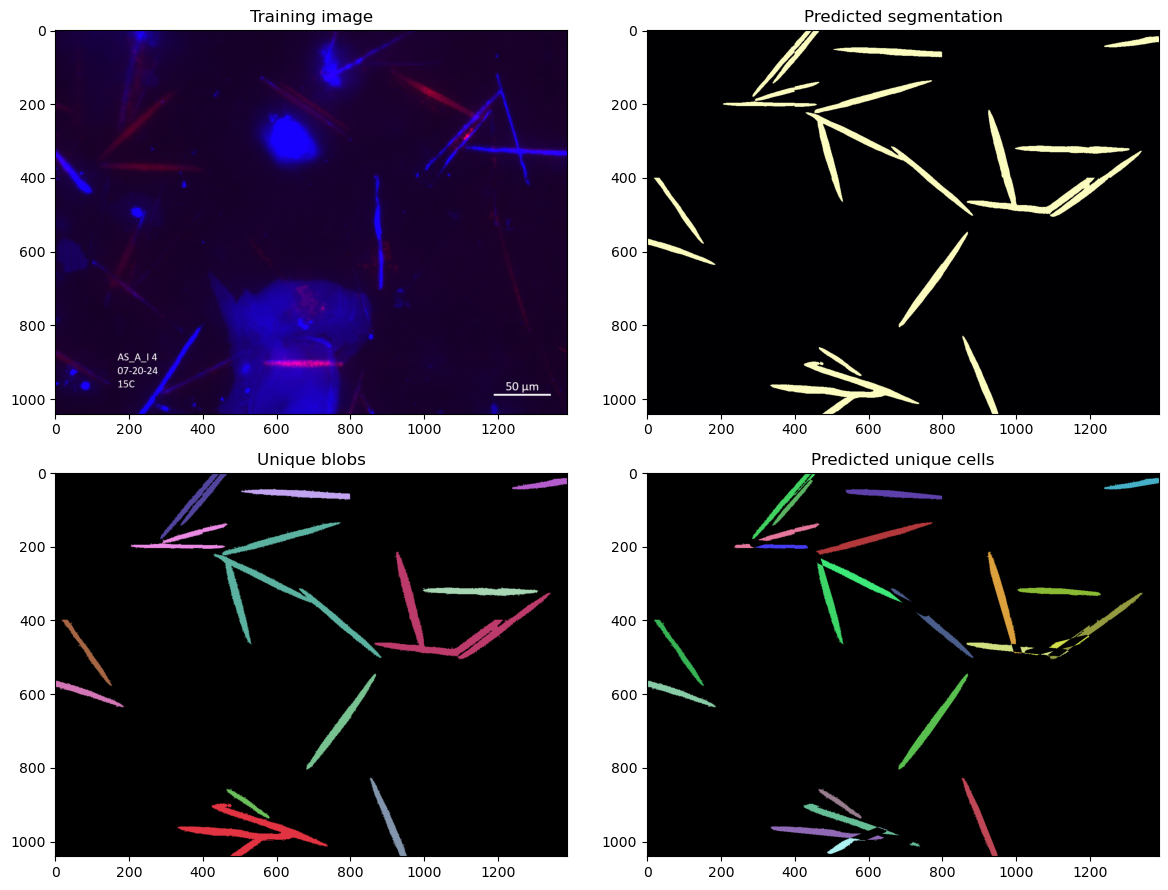

In [17]:
i=0
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
ax[0,0].imshow(imread("../../data/train_images/AS_A_I_15_4-20240720-C28.jpg"), cmap='magma')
ax[0,1].imshow(images[i], cmap='magma')
ax[1,0].imshow(blob_visualization, cmap='magma')
ax[1,1].imshow(img, cmap='magma')
ax[0,0].set_title("Training image")
ax[0,1].set_title("Predicted segmentation")
ax[1,0].set_title("Unique blobs")
ax[1,1].set_title("Predicted unique cells")
fig.tight_layout()

In [18]:
fig.savefig("sample_unique_cells.jpg")

Let's see how this existing approach performs on our full dataset.  I will also output the numbers and coordinates associated with each unique cell found to the ../../predictions/tsvs directory.

In [19]:
import os
for file in os.listdir("../../predictions/masks/"):
    if file.endswith(".jpg"):
        if not os.path.exists(f"../../predictions/tsvs/{file.replace('.jpg','.tsv')}"):
            mask=imread(f"../../predictions/masks/{file}")
            mask=mask/255
            coordinates_to_blobs,blob_sizes,blob_visualization=get_blobs(mask)    
            annotated_image,single_cell_image,coordinates_to_keep=separate_single_from_multi_cell(mask,coordinates_to_blobs,min_line_length=100,min_overlap_proportion=0.95)
            unique_cell_image=plot_blobs(coordinates_to_keep)
            cv2.imwrite(f"../../predictions/unique_cell_masks/{file}",unique_cell_image)
            output=open(f"../../predictions/tsvs/{file.replace('.jpg','.tsv')}","w")
            output.write("cell_number\tcell_coordinates\n")
            for cell_number in set(coordinates_to_keep.values()):
                output.write(str(cell_number)+"\t")
                for coordinates in coordinates_to_keep.keys():
                    if coordinates_to_keep[coordinates]==cell_number:
                        output.write(coordinates+";")
                output.write("\n")
            output.close()
            print(f"Done with {file}.")
                


The separation seems to do reasonably well on the images I tested, however there are cases where not all of the cells within a clump are returned.  This is certainly better than low specificity i.e. drawing cells where there are none), but still unfortunate.  Thankfully, we have a lot of cells to work with in our dataset and there is no reason to believe that clumps are more likely to be infected or uninfected.  As such, missing some of these cells is unlikely to affect the parasite infection rates calculated, which is the ultimate goal of the pipeline.